In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mahatiratusher/stroke-risk-prediction-dataset-v2")

print("Path to dataset files:", path)

100%|██████████| 240k/240k [00:00<00:00, 20.2MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/mahatiratusher/stroke-risk-prediction-dataset-v2/versions/1


In [ ]:
!pip install kagglehub -q

In [ ]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries installed and imported successfully!")


✅ Libraries installed and imported successfully!


In [ ]:
print("\n" + "="*50)
print("LOADING DATASET FROM KAGGLE CACHE")
print("="*50)

# Method 1: Using kagglehub (uses Colab cache automatically)
try:
    # Download dataset using kagglehub - this caches to /root/.cache/kagglehub/
    dataset_path = kagglehub.dataset_download('fedesoriano/stroke-prediction-dataset')
    print(f"✅ Dataset cached at: {dataset_path}")

    # Find the CSV file in the downloaded path
    import os
    csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]
    if csv_files:
        file_path = os.path.join(dataset_path, csv_files[0])
        df = pd.read_csv(file_path)
        print(f"✅ Loaded file: {csv_files[0]}")
    else:
        raise FileNotFoundError("No CSV file found")

except Exception as e:
    print(f"⚠️ kagglehub method failed: {e}")
    print("Trying alternative path...")

    # Method 2: Direct path for Kaggle notebooks
    import os
    if os.path.exists('/kaggle/input/stroke-risk-prediction-dataset-v2'):
        df = pd.read_csv('/kaggle/input/stroke-risk-prediction-dataset-v2/healthcare-dataset-stroke-data.csv')
        print("✅ Loaded from /kaggle/input/")
    else:
        # Method 3: Direct URL download as fallback
        print("Downloading directly from GitHub...")
        url = "https://raw.githubusercontent.com/santi-souza/stroke-eda-ml/main/stroke.csv"
        df = pd.read_csv(url)
        print("✅ Loaded from GitHub")

print(f"📊 Dataset shape: {df.shape}")
print(f"📊 Columns: {df.columns.tolist()}")


LOADING DATASET FROM KAGGLE CACHE
Using Colab cache for faster access to the 'stroke-prediction-dataset' dataset.
✅ Dataset cached at: /kaggle/input/stroke-prediction-dataset
✅ Loaded file: healthcare-dataset-stroke-data.csv
📊 Dataset shape: (5110, 12)
📊 Columns: ['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status', 'stroke']



EXPLORATORY DATA ANALYSIS

🔍 First 5 rows:
      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21   NaN     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  

🔍 Dataset I

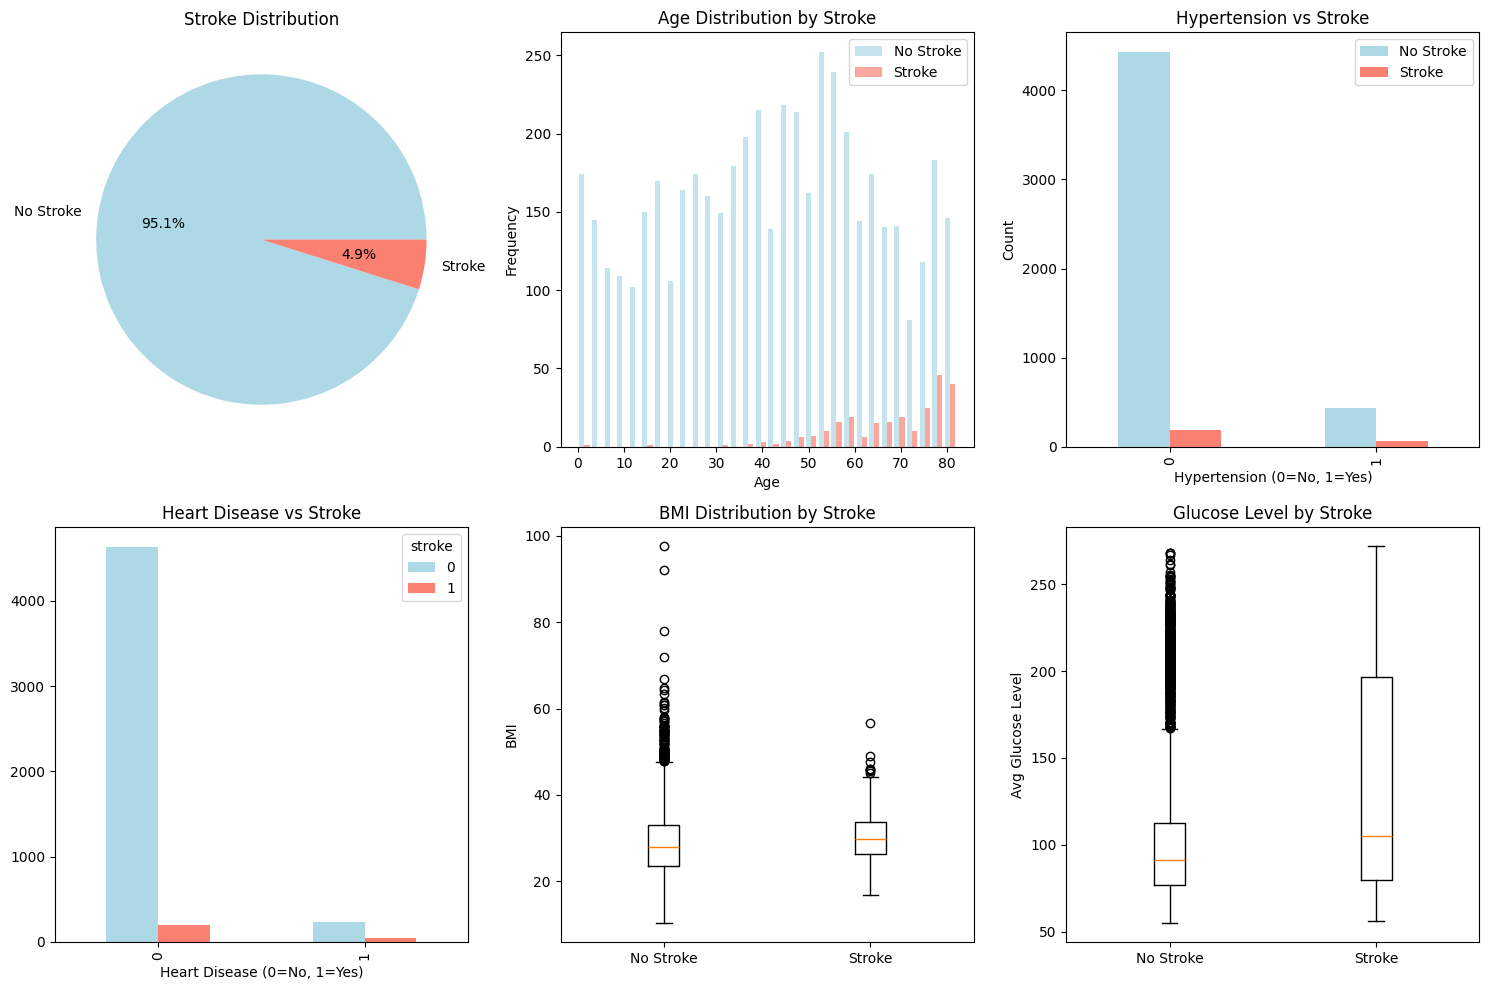

In [ ]:
print("\n" + "="*50)
print("EXPLORATORY DATA ANALYSIS")
print("="*50)

# First look at the data
print("\n🔍 First 5 rows:")
print(df.head())

print("\n🔍 Dataset Info:")
print(df.info())

print("\n🔍 Statistical Summary:")
print(df.describe())

print("\n🔍 Missing Values:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Target variable distribution
print("\n🔍 Target Variable Distribution (Stroke):")
stroke_counts = df['stroke'].value_counts()
print(stroke_counts)
print(f"Stroke Rate: {stroke_counts[1]/len(df)*100:.2f}%")

# Visualizations
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# Target distribution
axes[0, 0].pie(df['stroke'].value_counts(), labels=['No Stroke', 'Stroke'],
               autopct='%1.1f%%', colors=['lightblue', 'salmon'])
axes[0, 0].set_title('Stroke Distribution', fontsize=12)

# Age distribution by stroke
axes[0, 1].hist([df[df['stroke']==0]['age'], df[df['stroke']==1]['age']],
                label=['No Stroke', 'Stroke'], bins=30, alpha=0.7, color=['lightblue', 'salmon'])
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Age Distribution by Stroke')
axes[0, 1].legend()

# Hypertension vs Stroke
stroke_by_hypertension = pd.crosstab(df['hypertension'], df['stroke'])
stroke_by_hypertension.plot(kind='bar', ax=axes[0, 2], color=['lightblue', 'salmon'])
axes[0, 2].set_title('Hypertension vs Stroke')
axes[0, 2].set_xlabel('Hypertension (0=No, 1=Yes)')
axes[0, 2].set_ylabel('Count')
axes[0, 2].legend(['No Stroke', 'Stroke'])

# Heart Disease vs Stroke
stroke_by_heart = pd.crosstab(df['heart_disease'], df['stroke'])
stroke_by_heart.plot(kind='bar', ax=axes[1, 0], color=['lightblue', 'salmon'])
axes[1, 0].set_title('Heart Disease vs Stroke')
axes[1, 0].set_xlabel('Heart Disease (0=No, 1=Yes)')
# BMI distribution by stroke
axes[1, 1].boxplot([df[df['stroke']==0]['bmi'].dropna(), df[df['stroke']==1]['bmi'].dropna()],
                   labels=['No Stroke', 'Stroke'])
axes[1, 1].set_title('BMI Distribution by Stroke')
axes[1, 1].set_ylabel('BMI')

# Glucose level distribution by stroke
axes[1, 2].boxplot([df[df['stroke']==0]['avg_glucose_level'], df[df['stroke']==1]['avg_glucose_level']],
                   labels=['No Stroke', 'Stroke'])
axes[1, 2].set_title('Glucose Level by Stroke')
axes[1, 2].set_ylabel('Avg Glucose Level')

plt.tight_layout()
plt.show()

In [ ]:
print("\n" + "="*50)
print("DATA PREPROCESSING")
print("="*50)

# Make a copy for preprocessing
df_processed = df.copy()

# Drop 'id' column as it's not useful for prediction
if 'id' in df_processed.columns:
    df_processed = df_processed.drop('id', axis=1)
    print("✅ Dropped 'id' column")

# Handle categorical variables
categorical_cols = df_processed.select_dtypes(include=['object']).columns
print(f"\n🔍 Categorical columns: {categorical_cols.tolist()}")

# Label encoding for binary categorical variables
binary_cols = ['gender', 'ever_married', 'Residence_type']
for col in binary_cols:
    if col in df_processed.columns:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col])
        print(f"✅ Encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")
        # One-hot encoding for multi-class categorical variables
multi_cols = ['work_type', 'smoking_status']
df_processed = pd.get_dummies(df_processed, columns=multi_cols, drop_first=True)
print(f"✅ One-hot encoded {multi_cols}")

# Handle missing values in BMI (median imputation)
if 'bmi' in df_processed.columns:
    median_bmi = df_processed['bmi'].median()
    df_processed['bmi'].fillna(median_bmi, inplace=True)
    print(f"✅ Filled missing BMI values with median: {median_bmi:.2f}")

print(f"\n📊 Processed dataset shape: {df_processed.shape}")



DATA PREPROCESSING
✅ Dropped 'id' column

🔍 Categorical columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
✅ Encoded gender: {'Female': np.int64(0), 'Male': np.int64(1), 'Other': np.int64(2)}
✅ Encoded ever_married: {'No': np.int64(0), 'Yes': np.int64(1)}
✅ Encoded Residence_type: {'Rural': np.int64(0), 'Urban': np.int64(1)}
✅ One-hot encoded ['work_type', 'smoking_status']
✅ Filled missing BMI values with median: 28.10

📊 Processed dataset shape: (5110, 16)


In [ ]:
print("\n" + "="*50)
print("FEATURE ENGINEERING")
print("="*50)

# Define features and target
X = df_processed.drop('stroke', axis=1)
y = df_processed['stroke']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeatures list:\n{X.columns.tolist()}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n✅ Train set size: {X_train.shape[0]} samples")
print(f"✅ Test set size: {X_test.shape[0]} samples")
print(f"✅ Train stroke rate: {y_train.mean()*100:.2f}%")
print(f"✅ Test stroke rate: {y_test.mean()*100:.2f}%")
# Feature scaling
scaler = StandardScaler()
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

print(f"✅ Scaled numerical features: {numerical_cols}")

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print(f"\n✅ After SMOTE balancing:")
print(f"   Train shape: {X_train_balanced.shape}")
print(f"   Stroke rate: {y_train_balanced.mean()*100:.2f}%")



FEATURE ENGINEERING
Features shape: (5110, 15)
Target shape: (5110,)

Features list:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'Residence_type', 'avg_glucose_level', 'bmi', 'work_type_Never_worked', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'smoking_status_formerly smoked', 'smoking_status_never smoked', 'smoking_status_smokes']

✅ Train set size: 4088 samples
✅ Test set size: 1022 samples
✅ Train stroke rate: 4.87%
✅ Test stroke rate: 4.89%
✅ Scaled numerical features: ['age', 'avg_glucose_level', 'bmi']

✅ After SMOTE balancing:
   Train shape: (7778, 15)
   Stroke rate: 50.00%


In [ ]:
print("\n" + "="*50)
print("MODEL TRAINING & EVALUATION")
print("="*50)

# Define models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(random_state=42, probability=True)
}

# Cross-validation setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
results = {}

print("\n🔄 Training and evaluating models...\n")
for name, model in models.items():
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_balanced, y_train_balanced,
                                 cv=cv, scoring='f1')

    # Train on full balanced training set
    model.fit(X_train_balanced, y_train_balanced)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] if hasattr(model, 'predict_proba') else None

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None

    results[name] = {
        'cv_f1_mean': cv_scores.mean(),
        'cv_f1_std': cv_scores.std(),
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': auc,
        'model': model
    }
    print(f"📊 {name}:")
    print(f"   CV F1 Score: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"   Test Accuracy: {accuracy:.4f}")
    print(f"   Test Precision: {precision:.4f}")
    print(f"   Test Recall: {recall:.4f}")
    print(f"   Test F1 Score: {f1:.4f}")
    if auc:
        print(f"   Test AUC-ROC: {auc:.4f}")
    print()



MODEL TRAINING & EVALUATION

🔄 Training and evaluating models...

📊 Logistic Regression:
   CV F1 Score: 0.8079 (+/- 0.0089)
   Test Accuracy: 0.7642
   Test Precision: 0.1369
   Test Recall: 0.7200
   Test F1 Score: 0.2300
   Test AUC-ROC: 0.8262

📊 Random Forest:
   CV F1 Score: 0.9436 (+/- 0.0050)
   Test Accuracy: 0.8914
   Test Precision: 0.1139
   Test Recall: 0.1800
   Test F1 Score: 0.1395
   Test AUC-ROC: 0.7739

📊 Gradient Boosting:
   CV F1 Score: 0.8767 (+/- 0.0067)
   Test Accuracy: 0.8004
   Test Precision: 0.1500
   Test Recall: 0.6600
   Test F1 Score: 0.2444
   Test AUC-ROC: 0.7989

📊 XGBoost:
   CV F1 Score: 0.9437 (+/- 0.0026)
   Test Accuracy: 0.8963
   Test Precision: 0.1500
   Test Recall: 0.2400
   Test F1 Score: 0.1846
   Test AUC-ROC: 0.7694

📊 SVM:
   CV F1 Score: 0.8866 (+/- 0.0045)
   Test Accuracy: 0.7906
   Test Precision: 0.1204
   Test Recall: 0.5200
   Test F1 Score: 0.1955
   Test AUC-ROC: 0.7678




MODEL COMPARISON

📊 Model Performance Comparison:
                     accuracy  precision  recall      f1     auc
Logistic Regression    0.7642     0.1369    0.72  0.2300  0.8262
Random Forest          0.8914     0.1139    0.18  0.1395  0.7739
Gradient Boosting      0.8004     0.1500    0.66  0.2444  0.7989
XGBoost                0.8963     0.1500    0.24  0.1846  0.7694
SVM                    0.7906     0.1204    0.52  0.1955  0.7678

🏆 Best Model: Gradient Boosting (F1 Score: 0.2444)


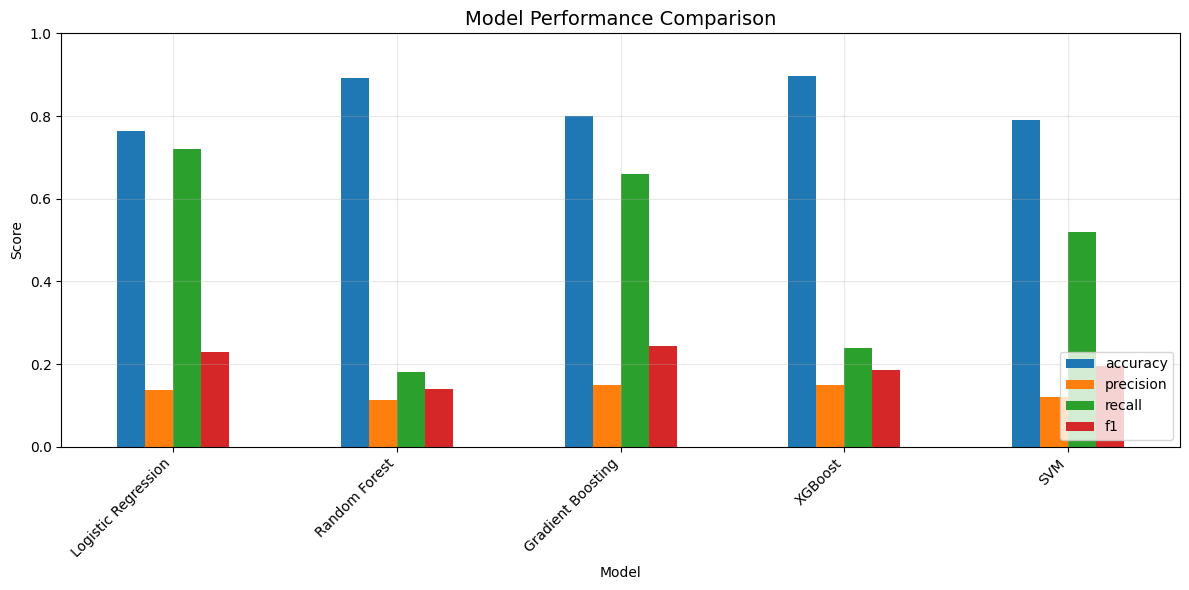

In [ ]:
print("\n" + "="*50)
print("MODEL COMPARISON")
print("="*50)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    model: {metric: results[model][metric] for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc']}
    for model in results.keys()
}).T

print("\n📊 Model Performance Comparison:")
print(comparison_df.round(4))

# Find best model
best_model_name = comparison_df['f1'].idxmax()
best_model = results[best_model_name]['model']
print(f"\n🏆 Best Model: {best_model_name} (F1 Score: {comparison_df.loc[best_model_name, 'f1']:.4f})")

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 6))
comparison_df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar', ax=ax)
ax.set_title('Model Performance Comparison', fontsize=14)
ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



BEST MODEL DETAILS: Gradient Boosting


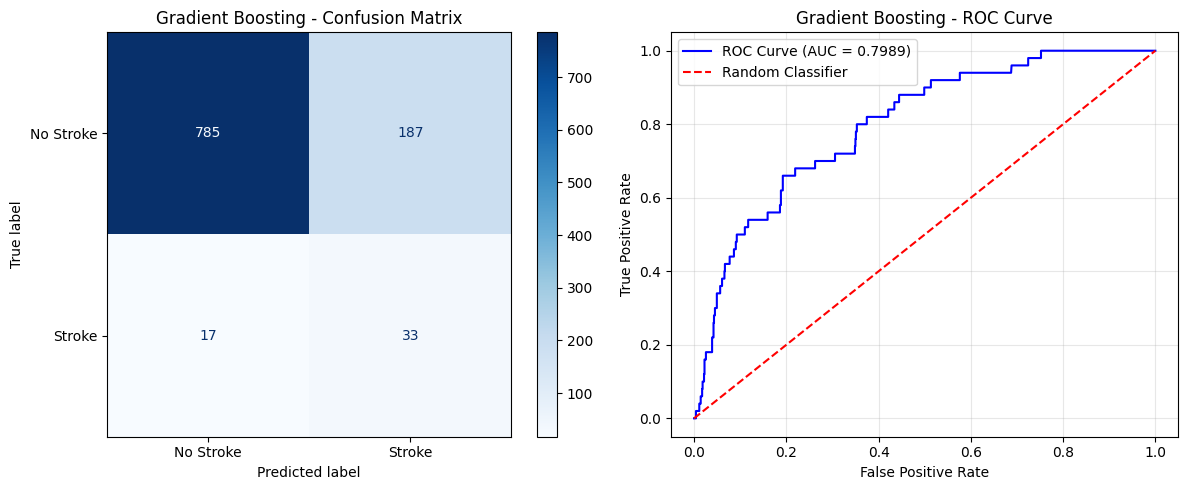


📋 Classification Report for Gradient Boosting:
              precision    recall  f1-score   support

   No Stroke       0.98      0.81      0.89       972
      Stroke       0.15      0.66      0.24        50

    accuracy                           0.80      1022
   macro avg       0.56      0.73      0.56      1022
weighted avg       0.94      0.80      0.85      1022



In [ ]:
print("\n" + "="*50)
print(f"BEST MODEL DETAILS: {best_model_name}")
print("="*50)

# Get predictions from best model
y_pred_best = best_model.predict(X_test_scaled)
y_pred_proba_best = best_model.predict_proba(X_test_scaled)[:, 1]

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Stroke', 'Stroke'])
disp.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title(f'{best_model_name} - Confusion Matrix', fontsize=12)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_best)
auc_score = results[best_model_name]['auc']
axes[1].plot(fpr, tpr, 'b-', label=f'ROC Curve (AUC = {auc_score:.4f})')
axes[1].plot([0, 1], [0, 1], 'r--', label='Random Classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'{best_model_name} - ROC Curve', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📋 Classification Report for {best_model_name}:")
print(classification_report(y_test, y_pred_best, target_names=['No Stroke', 'Stroke']))



FEATURE IMPORTANCE ANALYSIS

📊 Top 10 Most Important Features:
                           feature  importance
1                              age    0.781910
7                              bmi    0.056283
6                avg_glucose_level    0.052907
0                           gender    0.020490
9                work_type_Private    0.016916
10         work_type_Self-employed    0.014597
14           smoking_status_smokes    0.012227
3                    heart_disease    0.009230
12  smoking_status_formerly smoked    0.006913
2                     hypertension    0.006835


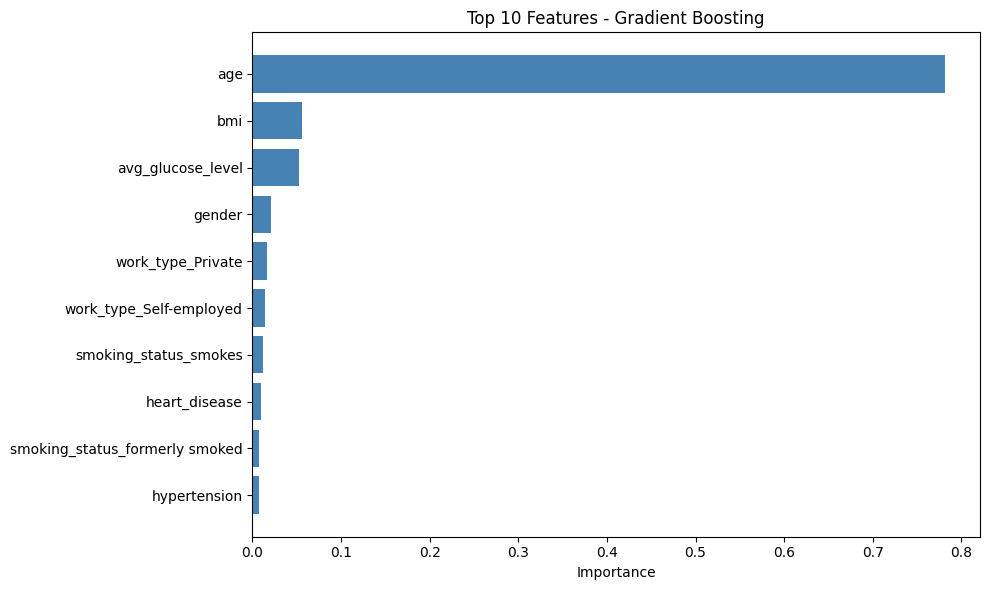

In [ ]:
if hasattr(best_model, 'feature_importances_'):
    print("\n" + "="*50)
    print("FEATURE IMPORTANCE ANALYSIS")
    print("="*50)

    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\n📊 Top 10 Most Important Features:")
    print(feature_importance.head(10))

    # Visualize
    plt.figure(figsize=(10, 6))
    plt.barh(feature_importance.head(10)['feature'], feature_importance.head(10)['importance'], color='steelblue')
    plt.xlabel('Importance')
    plt.title(f'Top 10 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


In [ ]:
print("\n" + "="*50)
print("HYPERPARAMETER TUNING")
print("="*50)

# Only run tuning for Random Forest (adjust as needed)
tune_model = input("\nWould you like to tune Random Forest? (yes/no): ").lower()

if tune_model == 'yes':
    print("\n🔄 Performing Grid Search for Random Forest...")

    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }

    rf = RandomForestClassifier(random_state=42)
    grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_balanced, y_train_balanced)

    print(f"\n✅ Best Parameters: {grid_search.best_params_}")
    print(f"✅ Best CV F1 Score: {grid_search.best_score_:.4f}")

    # Evaluate tuned model
    tuned_rf = grid_search.best_estimator_
    y_pred_tuned = tuned_rf.predict(X_test_scaled)
    tuned_f1 = f1_score(y_test, y_pred_tuned)

    print(f"✅ Tuned Model Test F1: {tuned_f1:.4f}")
    print(f"✅ Improvement: {(tuned_f1 - results['Random Forest']['f1'])*100:.2f}%")
else:
    print("⏭️ Skipping hyperparameter tuning")



HYPERPARAMETER TUNING

Would you like to tune Random Forest? (yes/no): yes

🔄 Performing Grid Search for Random Forest...
Fitting 3 folds for each of 81 candidates, totalling 243 fits

✅ Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
✅ Best CV F1 Score: 0.9364
✅ Tuned Model Test F1: 0.1527
✅ Improvement: 1.31%
